# Train until `all_test` accuracy threshold

Trains a registered model with the optimizer(s) in **`OPTIMIZER`** on **`TRAIN_K_SAMPLES`** MNIST train points with **equal samples per digit** (`TRAIN_K_SAMPLES` divisible by 10), using the same normalization and eval holdout as `MNISTWrapper._ensure_datasets`. **Phase A** trains full epochs (fixed shuffle per epoch) until `all_test` accuracy reaches **`THRESHOLD_ACC`**. **Phase B** restores the snapshot at the start of that epoch and **binary-searches** the first optimizer step inside the epoch where accuracy crosses the threshold; once the remaining bracket is fewer than `BS_LINEAR_BRACKET_THRESHOLD` (80) candidate steps, it loads the snapshot once, replays the warm-up steps to the bracket start, then continues one step at a time evaluating accuracy after each step and stops at the first crossing (so **`SAVE`** stores weights at that exact iteration, without evaluating every step). If `MAX_EPOCHS` is hit without crossing, no binary search is run.

In [ ]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm

_root = Path.cwd().resolve()
if not (_root / "models" / "__init__.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import optimizers  # noqa: F401 registers extractors
from compute_results.config_guard import (
    expand_registry_selection,
    build_pretrain_config,
    build_pretrain_report,
    save_pretrain_config,
    save_pretrain_report,
)


from scripts.run_simulation import _resolve_optimizer
from experiments.mnist.base import digit_indices, make_loader
from models import apply_model_weight_init, get_model, list_models, parse_he_init
from optimizers import get_extractor, list_extractors

In [ ]:
# --- config (matches ``input_configs/pretrain_base_then_a_multi.json`` for model / optim setup) ---
MODEL_TYPE = "DNN5Hidden64"
MODEL_CONFIG = {"activation": "relu"}
ACTIVATION = "relu"
HE_INIT = "all"
INIT_EPSILON = 1e-8

# Same as JSON ``optimizer`` + ``expand_registry_selection`` in ``run_simulation.main``
OPTIMIZER = 'AdamExtractor' # "AdaGradExtractor,GraftedShampooExtractor,PureShampooExtractor,SGDExtractor"

DATASET_SEED = 3003  # train-index selection and epoch batch order (shared across runs)
SEEDS = [6, 7, 14, 30, 31, 35, 51, 68, 90, 96]  # model weight init only; ``!SD`` in OUT_DIR

BASE_LR = 0.0005 if OPTIMIZER == "AdamExtractor" else 0.01

EXPERT = False
TRAIN_K_SAMPLES = 20000 if EXPERT else 1000  
THRESHOLD_ACC = 0.95 if EXPERT else 0.8
BATCH_SIZE = 1
MAX_EPOCHS = 200
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE = True
# ``!OPT`` → ``extractor.optimizer_id()``; ``!SD`` → seed (required when ``len(SEEDS) > 1``).
OUT_DIR = (
    f"save/{'expert_' if EXPERT else ''}optimizer_pretrained/!OPT/"
    if len(SEEDS) == 1
    else f"/home/garvalov/thesis/plateau_optimizer/network_analyzer/pretrained_models/"
    f"{'expert_' if EXPERT else ''}optimizer_pretrained/!OPT/!SD/"
)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
parse_he_init(HE_INIT)
print("Available models:", list_models())
print("Registered optimizers (extractors):", list_extractors())
assert MODEL_TYPE in list_models(), f"Unknown MODEL_TYPE={MODEL_TYPE!r}"

Available models: ['CNN3ConvK5Out32FC32', 'DNN5Hidden64']
Registered optimizers (extractors): ['AdaGradExtractor', 'AdamExtractor', 'GraftedShampooExtractor', 'PureShampooExtractor', 'SGDExtractor']


In [8]:
def build_mnist_train_and_eval(
    train_k_samples: int,
    batch_size: int,
    *,
    dataset_seed: int,
    data_root: str = "./data",
) -> tuple[Subset, DataLoader, DataLoader]:
    """Mirror ``MNISTWrapper._ensure_datasets`` (train stats, eval holdout, uniform K).

    Per-digit train pools are shuffled with *dataset_seed* before taking the first
    ``K // 10`` indices (after eval holdout).
    """
    n_digits = 10
    raw_train = datasets.MNIST(
        root=data_root, train=True, download=True, transform=transforms.ToTensor(),
    )
    pixels = raw_train.data.float() / 255.0
    mean, std = pixels.mean().item(), pixels.std().item()
    tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])

    full_train = datasets.MNIST(
        root=data_root, train=True, download=True, transform=tfm,
    )
    test_ds = datasets.MNIST(
        root=data_root, train=False, download=True, transform=tfm,
    )

    all_digits = tuple(range(n_digits))
    train_by_digit_indices = digit_indices(full_train, all_digits)
    eval_indices_list: list[int] = []
    for d in all_digits:
        eval_indices_list.extend(train_by_digit_indices[d][-5:])
    eval_indices_set = frozenset(eval_indices_list)
    if train_k_samples < 1:
        raise ValueError(f"train_k_samples must be >= 1, got {train_k_samples}")
    if train_k_samples % n_digits != 0:
        raise ValueError(
            f"train_k_samples={train_k_samples} must be divisible by n_digits={n_digits} "
            "for a uniform per-digit train split"
        )
    k_per_digit = train_k_samples // n_digits
    gen = torch.Generator()
    gen.manual_seed(dataset_seed)
    train_indices: list[int] = []
    for d in all_digits:
        pool = [i for i in train_by_digit_indices[d] if i not in eval_indices_set]
        if len(pool) < k_per_digit:
            raise ValueError(
                f"Digit {d}: need {k_per_digit} train samples after eval holdout, "
                f"only {len(pool)} available"
            )
        perm = torch.randperm(len(pool), generator=gen).tolist()
        train_indices.extend(pool[i] for i in perm[:k_per_digit])
    assert len(train_indices) == train_k_samples
    train_ds = Subset(full_train, train_indices)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    test_by_digit = digit_indices(test_ds, all_digits)
    all_test_idx = sum(test_by_digit.values(), [])
    all_test = make_loader(test_ds, all_test_idx, batch_size=len(test_ds), shuffle=False)
    return train_ds, train_loader, all_test


train_ds, train_loader, all_test = build_mnist_train_and_eval(
    TRAIN_K_SAMPLES, BATCH_SIZE, dataset_seed=DATASET_SEED,
)
print(
    f"dataset_seed={DATASET_SEED}  "
    f"Train size K={TRAIN_K_SAMPLES} ({TRAIN_K_SAMPLES // 10} per digit, uniform), "
    f"batches/epoch: {len(train_loader)}, all_test batches: {len(all_test)}"
)

dataset_seed=3003  Train size K=1000 (100 per digit, uniform), batches/epoch: 1000, all_test batches: 1


In [ ]:

def parse_optimizer_list(s: str) -> list[str]:
    return [p.strip() for p in s.split(",") if p.strip()]


def materialize_epoch_batches(
    train_ds: Subset,
    batch_size: int,
    epoch_idx: int,
    materialize_seed: int,
) -> list[tuple[torch.Tensor, torch.Tensor]]:
    """Fixed batch order for one epoch (replayed identically in Phase B)."""
    g = torch.Generator()
    g.manual_seed(materialize_seed + epoch_idx * 100_003)
    loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, generator=g,
    )
    return [(xb.clone(), yb.clone()) for xb, yb in loader]


def take_snapshot(model: torch.nn.Module, optimizer: torch.optim.Optimizer) -> dict:
    return {
        "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        "optimizer": copy.deepcopy(optimizer.state_dict()),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def load_snapshot(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    snap: dict,
    device: torch.device,
) -> None:
    model.load_state_dict({k: v.to(device) for k, v in snap["model"].items()})
    optimizer.load_state_dict(copy.deepcopy(snap["optimizer"]))

    torch.set_rng_state(snap["torch_rng"])
    if snap["cuda_rng"] is not None:
        torch.cuda.set_rng_state_all(snap["cuda_rng"])


@torch.no_grad()
def full_loader_loss_acc(
    model: torch.nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[float, float]:
    with torch.no_grad():
        model.eval()
        total_loss = 0.0
        correct = 0
        n = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            total_loss += F.cross_entropy(logits, yb, reduction="sum").item()
            correct += (logits.argmax(dim=-1) == yb).sum().item()
            n += yb.numel()
    return total_loss / n, correct / n


def train_first_n_batches(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: torch.nn.Module,
    batches: list[tuple[torch.Tensor, torch.Tensor]],
    n_steps: int,
    device: torch.device,
    *,
    mode: str = "train",
    bracket_lo: int | None = None,
    threshold: float | None = None,
    eval_loader: DataLoader | None = None,
    log_prefix: str | None = None,
) -> tuple[float, int] | tuple[float, int, float]:
    """Train on the first *n_steps* batches.

    mode='train' (default): plain training, returns (avg_loss, steps_done).
    mode='linear_search': warms up through the first *bracket_lo* steps without
        evaluation, then evaluates accuracy after every subsequent step until the
        first step that reaches *threshold*. Returns (avg_loss, crossing_k,
        crossing_acc) where crossing_k is the 1-indexed step at which the threshold
        was first met, or n_steps if it was not crossed inside the bracket.
        Requires bracket_lo, threshold, and eval_loader.
    """
    model.train()
    running = 0.0
    seen = 0
    m = min(n_steps, len(batches))

    if mode == "train":
        for i in range(m):
            xb, yb = batches[i]
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * yb.size(0)
            seen += yb.size(0)
        return running / max(seen, 1), m

    # mode == "linear_search"
    if bracket_lo is None or threshold is None or eval_loader is None:
        raise ValueError("bracket_lo, threshold, and eval_loader are required for mode='linear_search'")

    warmup = min(bracket_lo, m)
    for i in range(warmup):
        xb, yb = batches[i]
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * yb.size(0)
        seen += yb.size(0)

    crossing_k = m
    crossing_acc = float("nan")
    for i in range(warmup, m):
        model.train()
        xb, yb = batches[i]
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * yb.size(0)
        seen += yb.size(0)
        _, acc = full_loader_loss_acc(model, eval_loader, device)
        if log_prefix is not None:
            print(f"{log_prefix} step {i + 1}, all_test_acc={acc:.6f}")
        if acc >= threshold:
            crossing_k = i + 1
            crossing_acc = acc
            break

    return running / max(seen, 1), crossing_k, crossing_acc


BS_LINEAR_BRACKET_THRESHOLD = 80


def binary_search_first_threshold_step(
    *,
    slug: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: torch.nn.Module,
    batches: list[tuple[torch.Tensor, torch.Tensor]],
    snapshot_epoch_start: dict,
    threshold: float,
    device: torch.device,
    eval_loader: DataLoader,
    verify_first: bool = False,
) -> int:
    """Smallest k in 1..N with all_test acc >= threshold after k steps from snapshot (g(0) < threshold)."""
    n = len(batches)
    print(f"[{slug}] --- Phase B: binary search on crossing epoch ({n} steps) ---")
	
    if verify_first:
        load_snapshot(model, optimizer, snapshot_epoch_start, device)
        _, acc0 = full_loader_loss_acc(model, eval_loader, device)
        print(
            f"[{slug}] BS boundary g(0): eval after 0 steps, all_test_acc={acc0:.6f} "
            f"(expect < {threshold:.6f})"
        )
        if acc0 >= threshold:
            raise RuntimeError(
                f"[{slug}] g(0) already >= threshold; cannot bracket crossing inside this epoch."
            )
    	
        load_snapshot(model, optimizer, snapshot_epoch_start, device)
        train_first_n_batches(model, optimizer, criterion, batches, n, device)
        _, acc_full = full_loader_loss_acc(model, eval_loader, device)
        print(
            f"[{slug}] BS boundary g({n}): eval after full epoch, all_test_acc={acc_full:.6f} "
            f"(expect >= {threshold:.6f})"
        )
        if acc_full < threshold:
            raise RuntimeError(
                f"[{slug}] g(N) below threshold after replay; batch order may not match Phase A."
            )

    lo, hi = 0, n
    probe = 0
    while lo + 1 < hi:
        if hi - lo < BS_LINEAR_BRACKET_THRESHOLD:
            print(
                f"[{slug}] BS bracket ({lo}, {hi}) has {hi - lo} steps "
                f"(< {BS_LINEAR_BRACKET_THRESHOLD}); switching to in-place linear scan from step {lo}"
            )
            load_snapshot(model, optimizer, snapshot_epoch_start, device)
            _, crossing_k, crossing_acc = train_first_n_batches(
                model, optimizer, criterion, batches, hi, device,
                mode="linear_search",
                bracket_lo=lo,
                threshold=threshold,
                eval_loader=eval_loader,
                log_prefix=f"[{slug}] BS linear:",
            )
            print(
                f"[{slug}] BS linear scan done: first crossing at step {crossing_k}, "
                f"all_test_acc={crossing_acc:.6f}"
            )
            lo, hi = crossing_k - 1, crossing_k
            break

        mid = (lo + hi) // 2
        if mid == lo:
            mid = lo + 1
        probe += 1
        print(
            f"[{slug}] BS probe #{probe}: bracket step indices ({lo}, {hi}) "
            f"≈ ({100 * lo / n:.1f}%, {100 * hi / n:.1f}%] of epoch → train/eval at mid={mid}"
        )
        load_snapshot(model, optimizer, snapshot_epoch_start, device)
        train_first_n_batches(model, optimizer, criterion, batches, mid, device)
        _, acc_mid = full_loader_loss_acc(model, eval_loader, device)
        print(f"[{slug}] BS probe #{probe}: after {mid} steps, all_test_acc={acc_mid:.6f}")
        if acc_mid >= threshold:
            hi = mid
            print(f"[{slug}] BS probe #{probe}: acc >= threshold → hi ← {hi} (search left / earlier steps)")
        else:
            lo = mid
            print(f"[{slug}] BS probe #{probe}: acc < threshold → lo ← {lo} (search right / later steps)")

    print(
        f"[{slug}] BS finished: minimal k = {hi} with g({lo}) < {threshold:.4f} and g({hi}) >= {threshold:.4f}"
    )
    return hi


def run_training_until_threshold_with_refinement(
    *,
    slug: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: torch.nn.Module,
    train_ds: Subset,
    batch_size: int,
    materialize_seed: int,
    eval_loader: DataLoader,
    threshold_acc: float,
    max_epochs: int,
    device: torch.device,
) -> dict:
    """Phase A: full epochs (fixed shuffle per epoch). Phase B: exact crossing step in last epoch."""
    train_loss_hist: list[float] = []
    test_loss_hist: list[float] = []
    iter_snapshots: list[int] = []
    global_step = 0
    reached = False
    crossing_epoch_idx: int | None = None
    crossing_batches: list[tuple[torch.Tensor, torch.Tensor]] | None = None
    snapshot_at_crossing_start: dict | None = None

    epoch_start_snapshots: list[dict] = [take_snapshot(model, optimizer)]

    print(f"[{slug}] --- Phase A: full epochs until all_test >= {threshold_acc} ---")

    for epoch_idx in range(max_epochs):
        snap_before = epoch_start_snapshots[epoch_idx]
        assert snap_before is not None
        batches = materialize_epoch_batches(
            train_ds, batch_size, epoch_idx, materialize_seed,
        )
        load_snapshot(model, optimizer, snap_before, device)

        running = 0.0
        seen = 0
        desc = f"[{slug}] Phase A epoch {epoch_idx + 1}/{max_epochs}"
        for xb, yb in tqdm(batches, desc=desc, total=len(batches)):
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            global_step += 1
            running += loss.item() * yb.size(0)
            seen += yb.size(0)

        train_loss = running / max(seen, 1)
        test_loss, test_acc = full_loader_loss_acc(model, eval_loader, device)
        train_loss_hist.append(train_loss)
        test_loss_hist.append(test_loss)
        iter_snapshots.append(global_step)

        epoch_start_snapshots.append(take_snapshot(model, optimizer))

        print(
            f"[{slug}] Phase A epoch {epoch_idx + 1:3d}  iters={global_step:5d}  "
            f"train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  all_test_acc={test_acc:.4f}"
        )

        if test_acc >= threshold_acc:
            reached = True
            crossing_epoch_idx = epoch_idx
            crossing_batches = batches
            snapshot_at_crossing_start = snap_before
            break

    exact_step = global_step
    final_train_loss = train_loss_hist[-1] if train_loss_hist else float("nan")
    final_test_loss = test_loss_hist[-1] if test_loss_hist else float("nan")
    final_test_acc = float("nan")

    if reached and crossing_batches is not None and snapshot_at_crossing_start is not None:
        steps_before = global_step - len(crossing_batches)
        verify_first = any(ok in slug.lower() for ok in {"sgd","adam","adagrad"})
        print(f"verify_first: {verify_first} for {slug}")
        k = binary_search_first_threshold_step(
            slug=slug,
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            batches=crossing_batches,
            snapshot_epoch_start=snapshot_at_crossing_start,
            threshold=threshold_acc,
            device=device,
            eval_loader=eval_loader,
            verify_first=verify_first,
        )
        load_snapshot(model, optimizer, snapshot_at_crossing_start, device)
        final_train_loss, _ = train_first_n_batches(
            model, optimizer, criterion, crossing_batches, k, device,
        )
        final_test_loss, final_test_acc = full_loader_loss_acc(model, eval_loader, device)
        exact_step = steps_before + k
        iter_snapshots[-1] = exact_step
        train_loss_hist[-1] = final_train_loss
        test_loss_hist[-1] = final_test_loss
        print(
            f"[{slug}] Exact crossing: global optimizer step {exact_step} "
            f"(epoch {crossing_epoch_idx + 1} step {k}/{len(crossing_batches)}), "
            f"all_test_acc={final_test_acc:.6f}"
        )
    elif not reached:
        print(
            f"[{slug}] Phase A stopped at max_epochs={max_epochs} without reaching "
            f"threshold_acc={threshold_acc}."
        )

    print(f"[{slug}] Total optimizer iterations (reported): {exact_step}")

    return {
        "train": list(train_loss_hist),
        "test": list(test_loss_hist),
        "iters": list(iter_snapshots),
        "steps": exact_step,
        "reached": reached,
        "final_test_acc": final_test_acc,
    }


def resolve_save_root(out_dir_template: str, *, slug: str, seed: int) -> Path:
    """Expand ``!OPT`` and ``!SD`` placeholders in *out_dir_template*."""
    if "!OPT" not in out_dir_template:
        raise ValueError("OUT_DIR must contain the placeholder '!OPT'.")
    if "!SD" in out_dir_template:
        path = out_dir_template.replace("!SD", str(seed))
    else:
        path = out_dir_template
    path = path.replace("!OPT", slug).replace("grafted_shampoo", "graft_shampoo")
    return Path(path).expanduser()


def save_pretrained_checkpoint(
    *,
    save_root: Path,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    slug: str,
    opt_name: str,
    opt_class: str,
    pack: dict,
    seed: int,
    dataset_seed: int,
	pretrain_config: dict,
) -> None:
    save_root.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_root / "model.pt")
    torch.save(optimizer.state_dict(), save_root / "optimizer.pt")
    report = build_pretrain_report(
        pretrain_config=pretrain_config,
        training_result=pack,
        model_seed=seed,
        optimizer_name=opt_name,
        optimizer_class=opt_class,
        optimizer_id=slug,
    )
    save_pretrain_report(save_root, report)
    save_pretrain_config(save_root, pretrain_config)


    print(
        f"[seed={seed}][{slug}] Saved model + optimizer state at exact crossing "
        f"under {save_root.resolve()}"
    )


def train_all_optimizers_for_seed(
    seed: int,
    *,
    dataset_seed: int,
    train_ds: Subset,
    eval_loader: DataLoader,
    optimizer_names: list[str],
    out_dir_template: str,
    device: torch.device,
) -> dict[str, dict]:
    criterion = torch.nn.CrossEntropyLoss()
    results_by_opt: dict[str, dict] = {}

    for opt_name in optimizer_names:
        opt_class, opt_kwargs = _resolve_optimizer(opt_name.strip(), BASE_LR)
        extractor = get_extractor(opt_class, **opt_kwargs)
        slug = extractor.optimizer_id()
        materialize_seed = dataset_seed + sum(ord(c) for c in slug) % 1_000_000

        torch.manual_seed(seed)  # model init only; data / batch order use dataset_seed
        model = get_model(MODEL_TYPE, **MODEL_CONFIG).to(device)
        apply_model_weight_init(
            model,
            he_init=HE_INIT,
            init_epsilon=INIT_EPSILON,
            activation=ACTIVATION,
        )
        optimizer = extractor.create_optimizer(model.parameters())

        print(
            f"\n=== model_seed={seed}  dataset_seed={dataset_seed}  "
            f"optimizer {opt_name!r} -> {opt_class} (optimizer_id={slug}) ==="
        )

        pack = run_training_until_threshold_with_refinement(
            slug=slug,
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            train_ds=train_ds,
            batch_size=BATCH_SIZE,
            materialize_seed=materialize_seed,
            eval_loader=eval_loader,
            threshold_acc=THRESHOLD_ACC,
            max_epochs=MAX_EPOCHS,
            device=device,
        )

        results_by_opt[slug] = {
            "label": opt_name.strip(),
            "extractor": opt_class,
            "iters": pack["iters"],
            "train": pack["train"],
            "test": pack["test"],
            "steps": pack["steps"],
            "reached": pack["reached"],
            "final_test_acc": pack["final_test_acc"],
        }

        if SAVE:
            if not pack["reached"]:
                print(f"[seed={seed}][{slug}] SAVE skipped: threshold not reached.")
            else:
                save_root = resolve_save_root(out_dir_template, slug=slug, seed=seed)
                save_pretrained_checkpoint(
                    save_root=save_root,
                    model=model,
                    optimizer=optimizer,
                    slug=slug,
                    opt_name=opt_name.strip(),
                    opt_class=opt_class,
                    pack=pack,
                    seed=seed,
                    dataset_seed=dataset_seed,
                    pretrain_config=PRETRAIN_CONFIG,
                )

    return results_by_opt


optimizer_names = expand_registry_selection(
    parse_optimizer_list(OPTIMIZER),
    available=list_extractors(),
)
PRETRAIN_CONFIG = build_pretrain_config(
    model_class=MODEL_TYPE,
    model_config=MODEL_CONFIG,
    activation=ACTIVATION,
    optimizer_names=optimizer_names,
    base_lr=BASE_LR,
    batch_size=BATCH_SIZE,
    he_init=HE_INIT,
    init_epsilon=INIT_EPSILON,
    dataset_seed=DATASET_SEED,
    model_seeds=SEEDS,
    train_k_samples=TRAIN_K_SAMPLES,
    threshold_acc=THRESHOLD_ACC,
    max_epochs=MAX_EPOCHS,
    data_root="./data",
    expert=EXPERT,
    opt_extra_kwargs={},
)
if SAVE and len(SEEDS) > 1 and "!SD" not in OUT_DIR:
    raise ValueError("SAVE with multiple SEEDS requires '!SD' in OUT_DIR.")

results_by_seed: dict[int, dict[str, dict]] = {}

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n########## model_seed {seed} ({seed_idx + 1}/{len(SEEDS)}) ##########")
    results_by_seed[seed] = train_all_optimizers_for_seed(
        seed,
        dataset_seed=DATASET_SEED,
        train_ds=train_ds,
        eval_loader=all_test,
        optimizer_names=optimizer_names,
        out_dir_template=OUT_DIR,
        device=DEVICE,
    )

# Last seed — handy for quick inspection / single-seed plots below.
results_by_opt = results_by_seed[SEEDS[-1]]



########## model_seed 6 (1/10) ##########

=== model_seed=6  dataset_seed=3003  optimizer 'AdamExtractor' -> AdamExtractor (optimizer_id=adam_lr0.0005) ===
[adam_lr0.0005] --- Phase A: full epochs until all_test >= 0.8 ---


[adam_lr0.0005] Phase A epoch 1/200: 100%|██████████| 1000/1000 [00:00<00:00, 1152.69it/s]


[adam_lr0.0005] Phase A epoch   1  iters= 1000  train_loss=1.1715  test_loss=0.7223  all_test_acc=0.7563


[adam_lr0.0005] Phase A epoch 2/200: 100%|██████████| 1000/1000 [00:00<00:00, 1151.09it/s]


[adam_lr0.0005] Phase A epoch   2  iters= 2000  train_loss=0.5088  test_loss=0.6786  all_test_acc=0.7930


...

[adam_lr0.0005] Phase A epoch   3  iters= 3000  train_loss=0.3624  test_loss=0.5151  all_test_acc=0.8369
verify_first: True for adam_lr0.0005
[adam_lr0.0005] --- Phase B: binary search on crossing epoch (1000 steps) ---
[adam_lr0.0005] BS boundary g(0): eval after 0 steps, all_test_acc=0.789600 (expect < 0.800000)
[adam_lr0.0005] BS boundary g(1000): eval after full epoch, all_test_acc=0.836900 (expect >= 0.800000)
[adam_lr0.0005] BS probe #1: bracket step indices (0, 1000) ≈ (0.0%, 100.0%] of epoch → train/eval at mid=500
[adam_lr0.0005] BS probe #1: after 500 steps, all_test_acc=0.851900
[adam_lr0.0005] BS probe #1: acc >= threshold → hi ← 500 (search left / earlier steps)
[adam_lr0.0005] BS probe #2: bracket step indices (0, 500) ≈ (0.0%, 50.0%] of epoch → train/eval at mid=250
[adam_lr0.0005] BS probe #2: after 250 steps, all_test_acc=0.834500
[adam_lr0.0005] BS probe #2: acc >= threshold → hi ← 250 (search left / earlier steps)
[adam_lr0.0005] BS probe #3: bracket step indices (0,

[adam_lr0.0005] Phase A epoch 1/200: 100%|██████████| 1000/1000 [00:00<00:00, 1122.60it/s]


[adam_lr0.0005] Phase A epoch   1  iters= 1000  train_loss=1.2127  test_loss=0.6905  all_test_acc=0.7755


[adam_lr0.0005] Phase A epoch 2/200: 100%|██████████| 1000/1000 [00:00<00:00, 1091.34it/s]


[adam_lr0.0005] Phase A epoch   2  iters= 2000  train_loss=0.5928  test_loss=0.5939  all_test_acc=0.8074
verify_first: True for adam_lr0.0005
[adam_lr0.0005] --- Phase B: binary search on crossing epoch (1000 steps) ---
[adam_lr0.0005] BS boundary g(0): eval after 0 steps, all_test_acc=0.775500 (expect < 0.800000)
[adam_lr0.0005] BS boundary g(1000): eval after full epoch, all_test_acc=0.807400 (expect >= 0.800000)
[adam_lr0.0005] BS probe #1: bracket step indices (0, 1000) ≈ (0.0%, 100.0%] of epoch → train/eval at mid=500
[adam_lr0.0005] BS probe #1: after 500 steps, all_test_acc=0.806700
[adam_lr0.0005] BS probe #1: acc >= threshold → hi ← 500 (search left / earlier steps)
[adam_lr0.0005] BS probe #2: bracket step indices (0, 500) ≈ (0.0%, 50.0%] of epoch → train/eval at mid=250
[adam_lr0.0005] BS probe #2: after 250 steps, all_test_acc=0.699600
[adam_lr0.0005] BS probe #2: acc < threshold → lo ← 250 (search right / later steps)
[adam_lr0.0005] BS probe #3: bracket step indices (250,

In [10]:
# Peek at one optimizer from the last seed.
next(iter(results_by_opt.values())) if results_by_opt else None

{'label': 'AdamExtractor',
 'extractor': 'AdamExtractor',
 'iters': [1000, 1388],
 'train': [1.2127084110679716, 0.6951665609049275],
 'test': [0.69045908203125, 0.623351220703125],
 'steps': 1388,
 'reached': True,
 'final_test_acc': 0.8038}

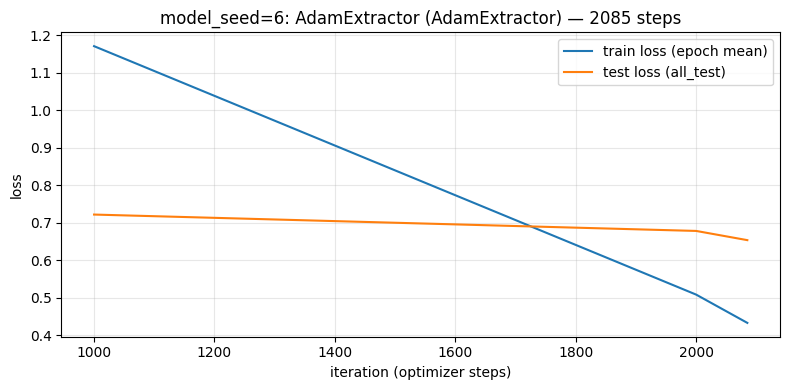

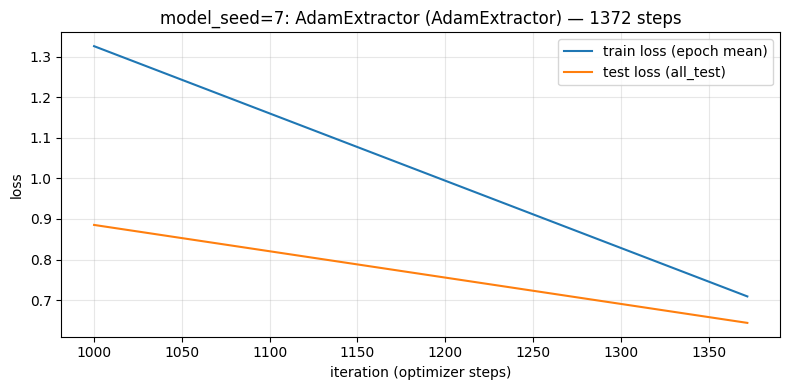

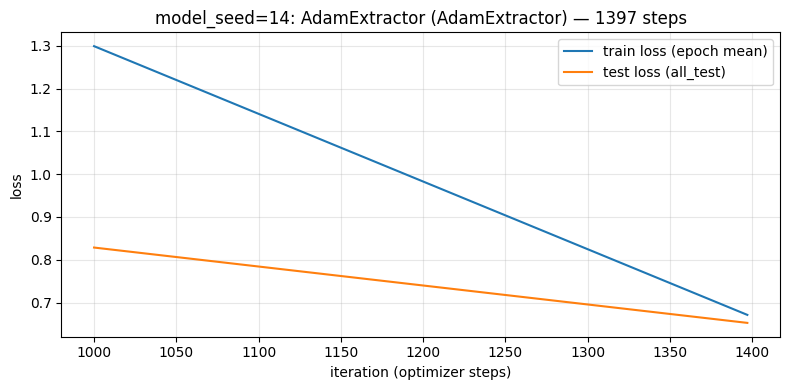

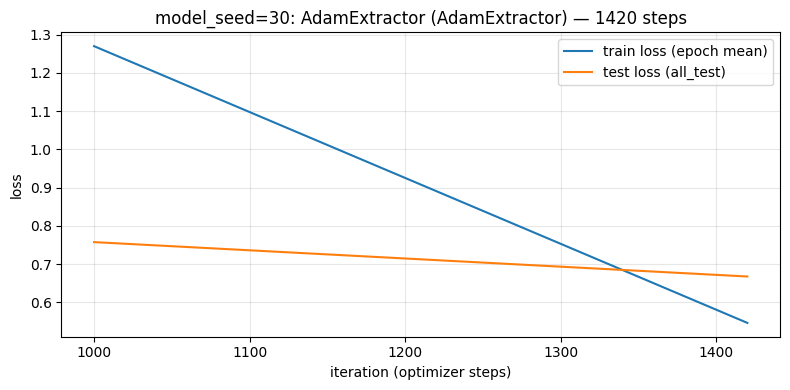

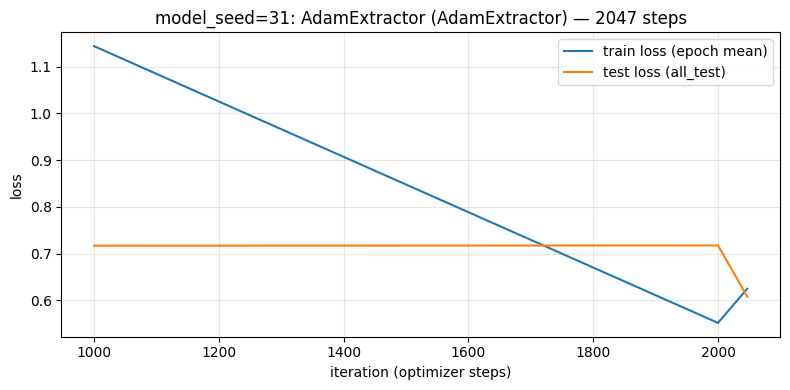

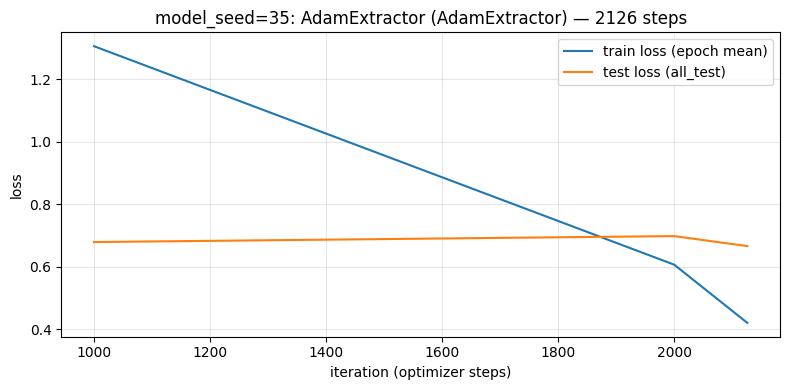

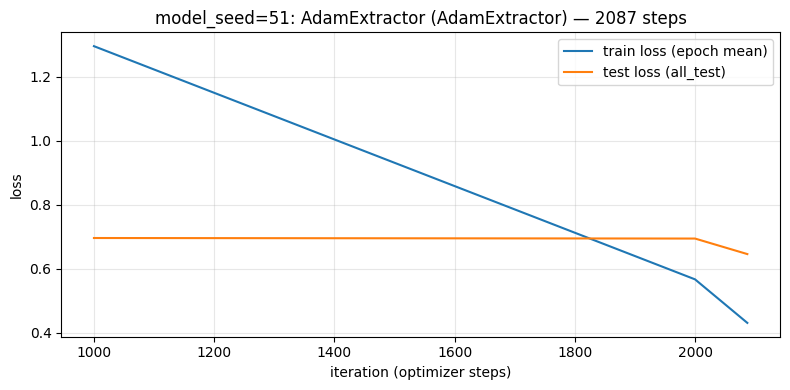

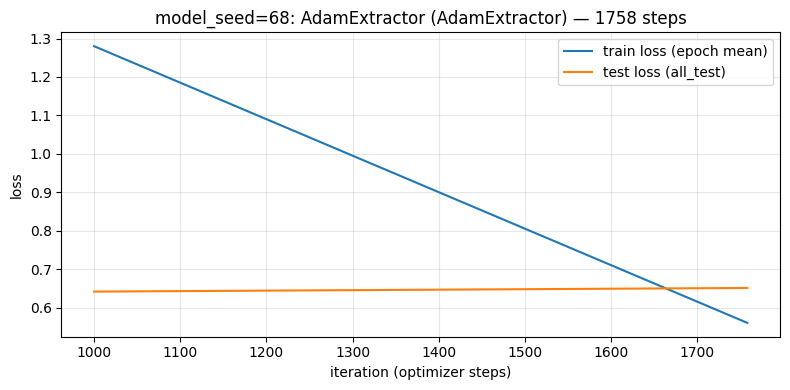

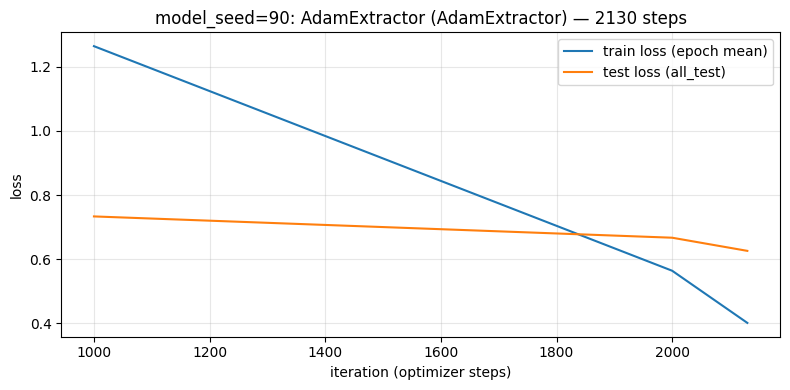

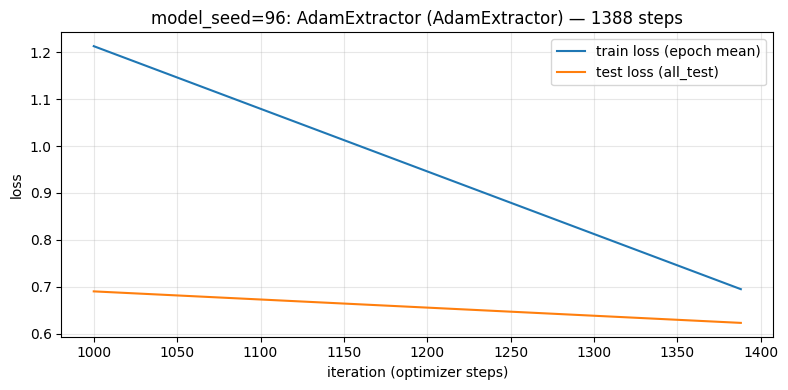

In [11]:
def plot_results_by_opt(results: dict[str, dict], *, title_suffix: str = "") -> None:
    n_opts = len(results)
    if n_opts == 0:
        print("No results to plot.")
        return
    if n_opts == 1:
        fig, ax = plt.subplots(figsize=(8, 4))
        axes = [ax]
    else:
        fig, axes = plt.subplots(n_opts, 1, figsize=(8, 3.2 * n_opts), squeeze=False)
        axes = axes.flatten()

    for ax, slug in zip(axes, results.keys()):
        pack = results[slug]
        ax.plot(pack["iters"], pack["train"], label="train loss (epoch mean)")
        ax.plot(pack["iters"], pack["test"], label="test loss (all_test)")
        title = f'{pack["label"]} ({pack["extractor"]}) — {pack["steps"]} steps'
        if title_suffix:
            title = f"{title_suffix}: {title}"
        ax.set_title(title)
        ax.set_xlabel("iteration (optimizer steps)")
        ax.set_ylabel("loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if len(SEEDS) == 1:
    plot_results_by_opt(results_by_opt)
else:
    for seed in SEEDS:
        plot_results_by_opt(results_by_seed[seed], title_suffix=f"model_seed={seed}")